##### LSTM Network - Prediction v9 (return-first multi-task model)\n\nThis notebook follows the same project workflow as the existing v7 example. The notebook remains intentionally thin: `StockPrediction`, `StockData`, `LongShortTermMemory`, `Plotter`, `train_LSTM_network` and `InferenceRunner` contain the implementation. v9 changes the target to next-session log returns and trains shared direction, expected-return and q10/q50/q90 heads.\n

In [1]:
%%capture
%pip install -r requirements.txt

In [2]:
# Copyright 2020-2026 Jordi Corbilla. All Rights Reserved.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.
# ==============================================================================

import os
import warnings
import secrets
import pandas as pd
import argparse
import numpy as np
import pickle
import json
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
for candidate in [REPO_ROOT, *REPO_ROOT.parents]:
    if (candidate / 'stock_prediction_class.py').exists():
        REPO_ROOT = candidate
        break
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

from stock_prediction_class import StockPrediction
from stock_prediction_lstm import LongShortTermMemory
from stock_prediction_numpy import StockData
from stock_prediction_plotter import Plotter
from stock_prediction_readme_generator import ReadmeGenerator
from stock_prediction_deep_learning import train_LSTM_network

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # or '3' to suppress all messages

# Suppress other warnings
warnings.filterwarnings("ignore", category=UserWarning, module="tensorflow")
warnings.filterwarnings("ignore", message=".*np.object.*", category=FutureWarning)

import tensorflow as tf
import matplotlib.pyplot as plt
from datetime import timedelta, datetime
from pandas.tseries.offsets import BDay

os.environ["PATH"] += os.pathsep + 'C:/Program Files (x86)/Graphviz2.38/bin/'

2026-09-27 06:07:48.791180: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1790489268.805223    2569 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1790489268.809328    2569 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Ticker: ^FTSE
Start Date: 2017-01-01
Validation Date: 2024-10-16
Model Version: v9
Target: next-session log return
Test Run Folder: ^FTSE_v9_20260927_48af9d8aaa64313b


/opt/hostedtoolcache/Python/3.12.14/x64/lib/python3.12/site-packages/yfinance/scrapers/quote.py:702: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  start = pd.Timestamp.utcnow().floor("D") - datetime.timedelta(days=365 // 2)
/opt/hostedtoolcache/Python/3.12.14/x64/lib/python3.12/site-packages/yfinance/scrapers/quote.py:704: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end = pd.Timestamp.utcnow().ceil("D")


End Date: 2026-09-27


/opt/hostedtoolcache/Python/3.12.14/x64/lib/python3.12/site-packages/yfinance/scrapers/history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


mean: [0.57087905]
max 1.0
min 0.0
Std dev: [0.04856946]
plotting Data and Histogram


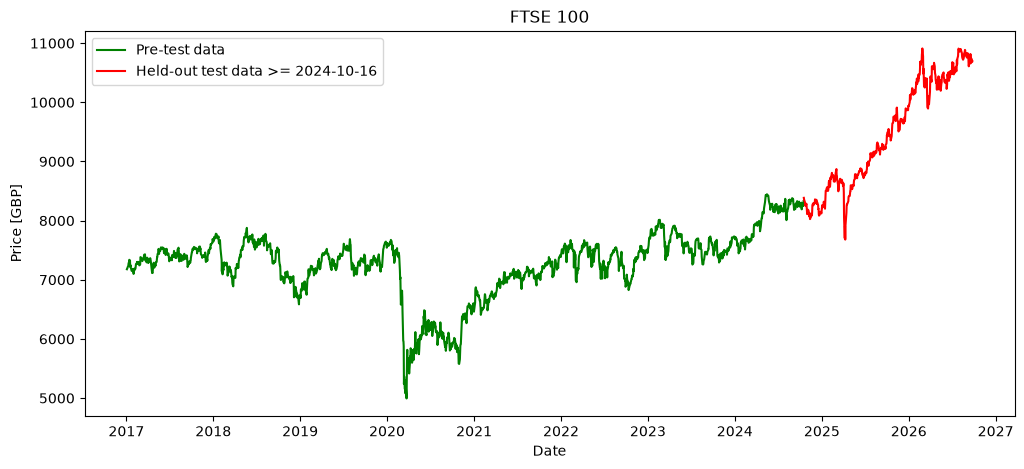

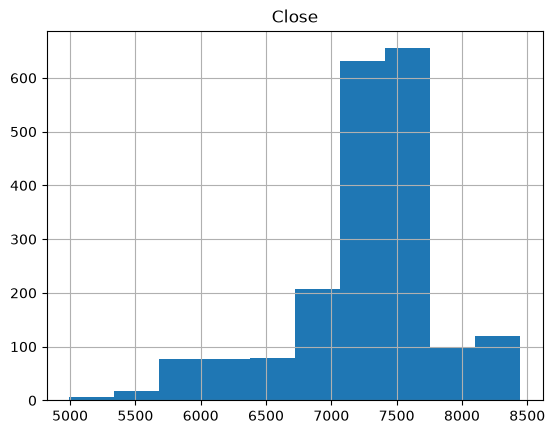

2026-09-27 06:07:53.551832: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "return_multitask_lstm_v9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ market_window       │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_lstm_1       │ (None, 60, 128)   │     66,560 │ market_window[0]… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dropout_1    │ (None, 60, 128)   │          0 │ shared_lstm_1[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_lstm_2       │ (None, 64)        │     49,408 │ shared_dropout_1… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dropout_2    │ (None, 64)        │          0 │ shared_lstm_2[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ median_return       │ (None, 1)         │         65 │ shared_dropout_2… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lower_distance      │ (None, 1)         │         65 │ shared_dropout_2… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ upper_distance      │ (None, 1)         │         65 │ shared_dropout_2… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q10 (Subtract)      │ (None, 1)         │          0 │ median_return[0]… │
│                     │                   │            │ lower_distance[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q90 (Add)           │ (None, 1)         │          0 │ median_return[0]… │
│                     │                   │            │ upper_distance[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ direction (Dense)   │ (None, 1)         │         65 │ shared_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expected_return     │ (None, 1)         │         65 │ shared_dropout_2… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ quantiles           │ (None, 3)         │          0 │ q10[0][0],        │
│ (Concatenate)       │                   │            │ median_return[0]… │
│                     │                   │            │ q90[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 116,293 (454.27 KB)

 Trainable params: 116,293 (454.27 KB)

...

161/162 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - direction_accuracy: 0.5161 - direction_loss: 0.6936 - expected_return_MSE: 0.0044 - expected_return_loss: 0.0022 - loss: 0.1832 - quantiles_loss: 0.0153


Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


162/162 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - direction_accuracy: 0.5167 - direction_loss: 0.6935 - expected_return_MSE: 0.0044 - expected_return_loss: 0.0022 - loss: 0.1832 - quantiles_loss: 0.0153 - val_direction_accuracy: 0.5245 - val_direction_loss: 0.6931 - val_expected_return_MSE: 0.0014 - val_expected_return_loss: 7.0977e-04 - val_loss: 0.1796 - val_quantiles_loss: 0.0111 - learning_rate: 0.0010


Epoch 8: early stopping


saving v9 return multi-task model
plotting v9 architecture


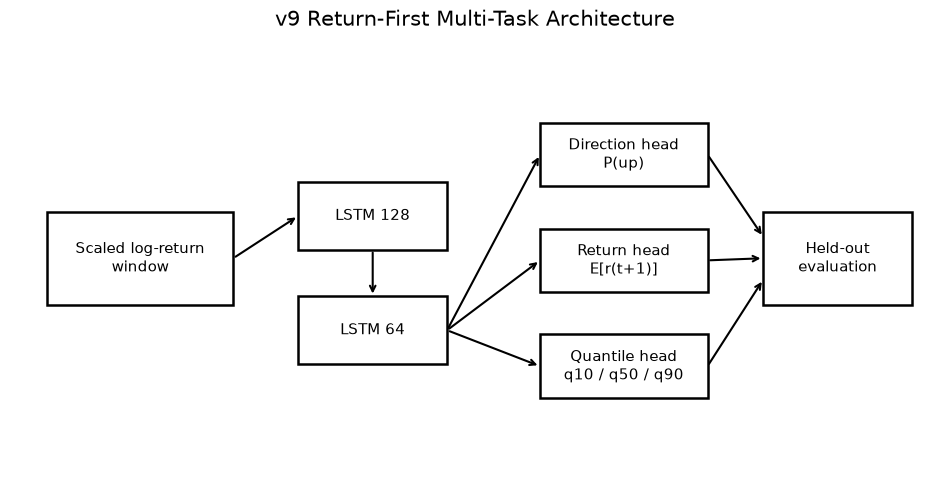

plotting loss


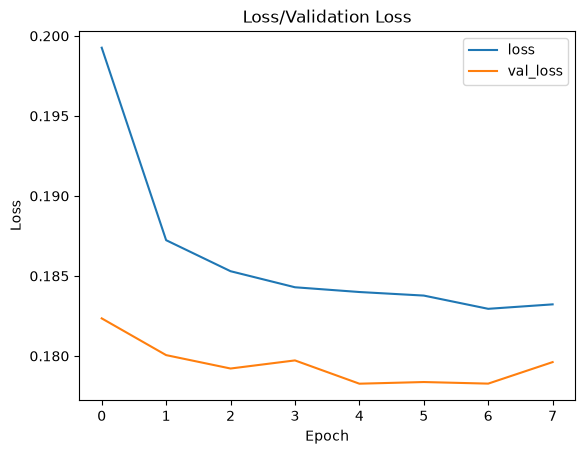

plotting MSE


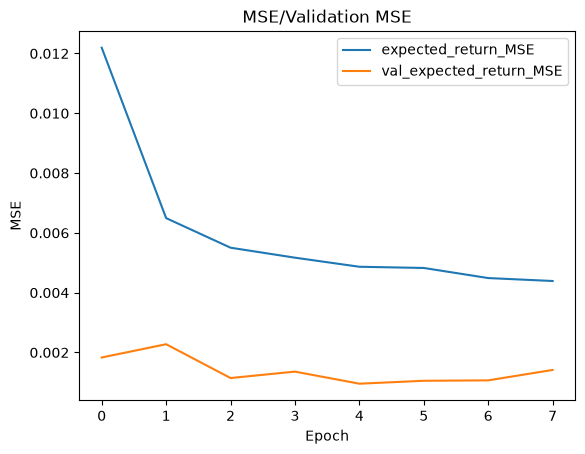

display the content of the model


2026-09-27 06:08:39.643533: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_17}}


16/16 - 0s - 17ms/step - direction_accuracy: 0.5540 - direction_loss: 0.6874 - expected_return_MSE: 0.0019 - expected_return_loss: 9.2834e-04 - loss: 0.1787 - quantiles_loss: 0.0120


direction_accuracy :  0.5539714694023132
direction_loss :  0.6874207854270935
expected_return_MSE :  0.0018641500500962138
expected_return_loss :  0.0009283439721912146
loss :  0.17874851822853088
quantiles_loss :  0.011951187625527382

plotting prediction results


 1/16 ━━━━━━━━━━━━━━━━━━━━ 3s 239ms/step

...

 9/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

13/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


Return forecast metrics: {'return_rmse': 0.00871206992304801, 'return_mae': 0.006640264516670029, 'rmse_skill_vs_zero': -0.1655746428553777, 'direction_accuracy': 0.4460285132382892, 'direction_head_accuracy': 0.5539714867617108, 'delta_ic': -0.053584143721277414, 'q10_q90_coverage': 0.9144602851323829}
plotting predictions


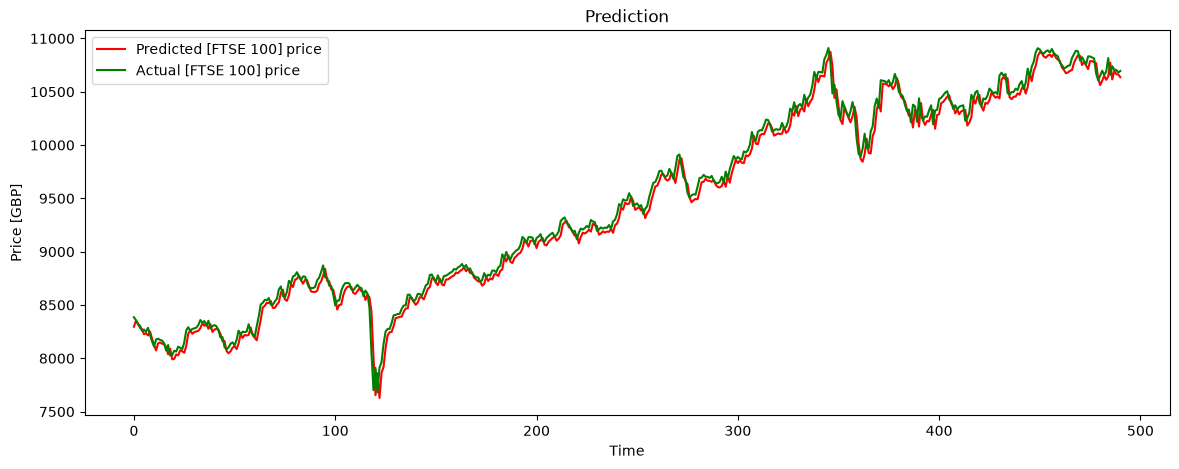

Forecast metrics: {'rmse': 81.33552726840338, 'mae': 62.55029774856063, 'directional_accuracy': 0.4460285132382892, 'rmse_skill_vs_naive': -0.16849522288755825}
prediction is finished


In [3]:
STOCK_TICKER = "^FTSE"
STOCK_START_DATE = pd.to_datetime('2017-01-01')
end_date = datetime.today()
duration = end_date - STOCK_START_DATE
STOCK_VALIDATION_DATE = STOCK_START_DATE + 0.8 * duration

MODEL_VERSION = 'v9'
EPOCHS = 20
BATCH_SIZE = 10
TIME_STEPS = 60
USE_RETURNS = True
VALIDATION_FRACTION = 0.15
SEED = 42
FORECAST_DAYS = 1

TODAY_RUN = datetime.today().strftime("%Y%m%d")
TOKEN = STOCK_TICKER + '_v9_' + TODAY_RUN + '_' + secrets.token_hex(8)
GITHUB_URL = "https://github.com/JordiCorbilla/stock-prediction-deep-neural-learning/raw/master/"

print('Ticker: ' + STOCK_TICKER)
print('Start Date: ' + STOCK_START_DATE.strftime("%Y-%m-%d"))
print('Validation Date: ' + STOCK_VALIDATION_DATE.strftime("%Y-%m-%d"))
print('Model Version: ' + MODEL_VERSION)
print('Target: next-session log return')
print('Test Run Folder: ' + TOKEN)

PROJECT_FOLDER = os.path.join(os.getcwd(), TOKEN)
if not os.path.exists(PROJECT_FOLDER):
    os.makedirs(PROJECT_FOLDER)

stock_prediction = StockPrediction(
    STOCK_TICKER,
    STOCK_START_DATE,
    STOCK_VALIDATION_DATE,
    PROJECT_FOLDER,
    GITHUB_URL,
    EPOCHS,
    TIME_STEPS,
    TOKEN,
    BATCH_SIZE,
)

train_LSTM_network(
    stock_prediction,
    use_returns=USE_RETURNS,
    model_version=MODEL_VERSION,
    forecast_horizon=FORECAST_DAYS,
    trend_window=60,
    validation_fraction=VALIDATION_FRACTION,
    seed=SEED,
)


## Infer the Future Data (Predictions)\n\nThe same `InferenceRunner` used by the existing project loads the saved v9 model and recursively forecasts future log returns, which are converted back into prices for the familiar future-price chart.\n

2.18.1


/opt/hostedtoolcache/Python/3.12.14/x64/lib/python3.12/site-packages/yfinance/scrapers/history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


Latest Stock Price
10695.2998046875
Latest Date
2026-09-25 00:00:00


Model: "return_multitask_lstm_v9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ market_window       │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_lstm_1       │ (None, 60, 128)   │     66,560 │ market_window[0]… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dropout_1    │ (None, 60, 128)   │          0 │ shared_lstm_1[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_lstm_2       │ (None, 64)        │     49,408 │ shared_dropout_1… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dropout_2    │ (None, 64)        │          0 │ shared_lstm_2[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ median_return       │ (None, 1)         │         65 │ shared_dropout_2… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lower_distance      │ (None, 1)         │         65 │ shared_dropout_2… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ upper_distance      │ (None, 1)         │         65 │ shared_dropout_2… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q10 (Subtract)      │ (None, 1)         │          0 │ median_return[0]… │
│                     │                   │            │ lower_distance[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q90 (Add)           │ (None, 1)         │          0 │ median_return[0]… │
│                     │                   │            │ upper_distance[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ direction (Dense)   │ (None, 1)         │         65 │ shared_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expected_return     │ (None, 1)         │         65 │ shared_dropout_2… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ quantiles           │ (None, 3)         │          0 │ q10[0][0],        │
│ (Concatenate)       │                   │            │ median_return[0]… │
│                     │                   │            │ q90[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

...

Inference progress: 6/30
Inference progress: 6/30
Inference progress: 9/30
Inference progress: 9/30


Inference progress: 12/30
Inference progress: 12/30
Inference progress: 15/30
Inference progress: 15/30


Inference progress: 18/30
Inference progress: 18/30
Inference progress: 21/30
Inference progress: 21/30


Inference progress: 24/30
Inference progress: 24/30
Inference progress: 27/30
Inference progress: 27/30


Inference progress: 30/30
Sanity check - next day delta: -0.41%


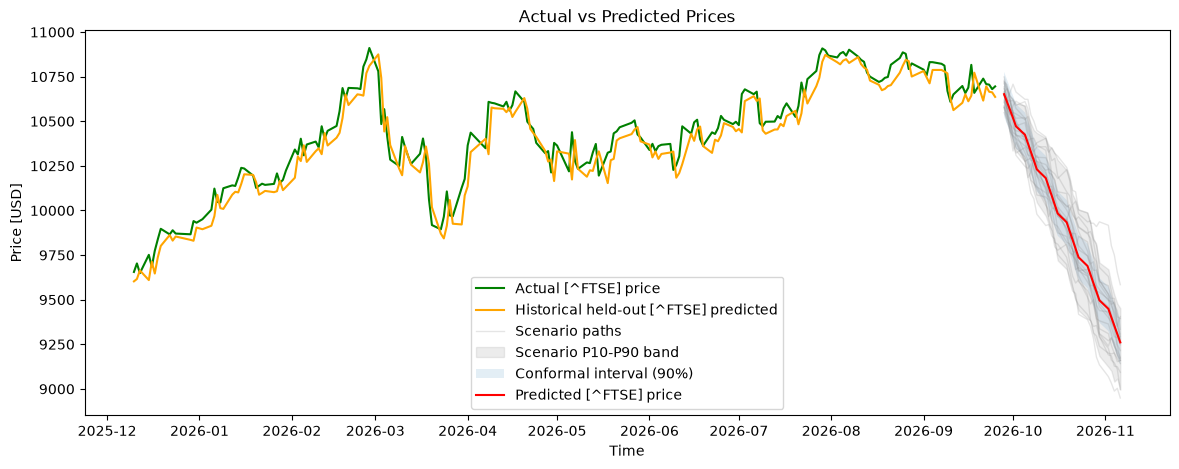

In [4]:
DIRECTION_THRESHOLD = 0.55
MAG_CLIP_PCT = 90
BLEND_ALPHA = 1.0

STOCHASTIC_PATHS = 50
STOCHASTIC_SEED = 42
STOCHASTIC_SIGMA_MULT = 0.6
STOCHASTIC_LOOKBACK = 120

from stock_prediction_deep_learning_inference import InferenceRunner

FORECAST_DAYS = 30
USE_BUSINESS_DAYS = True
PLOT_HISTORY_DAYS = 200
USE_RETURNS = True
USE_DELTAS = False
CLIP_NEGATIVE = True
CONFORMAL_COVERAGE = 0.90
EXCHANGE_CALENDAR = "XLON"

runner = InferenceRunner(
    run_folder=PROJECT_FOLDER,
    ticker=STOCK_TICKER,
    start_date=STOCK_START_DATE,
    validation_date=STOCK_VALIDATION_DATE,
    github_url=GITHUB_URL,
    epochs=EPOCHS,
    time_steps=TIME_STEPS,
    token=TOKEN,
    batch_size=BATCH_SIZE,
    forecast_days=FORECAST_DAYS,
    use_business_days=USE_BUSINESS_DAYS,
    plot_history_days=PLOT_HISTORY_DAYS,
    use_returns=USE_RETURNS,
    use_deltas=USE_DELTAS,
    clip_negative=CLIP_NEGATIVE,
    blend_alpha=BLEND_ALPHA,
    direction_threshold=DIRECTION_THRESHOLD,
    mag_clip_pct=MAG_CLIP_PCT,
    stochastic_paths=STOCHASTIC_PATHS,
    stochastic_seed=STOCHASTIC_SEED,
    stochastic_sigma_mult=STOCHASTIC_SIGMA_MULT,
    stochastic_lookback=STOCHASTIC_LOOKBACK,
    conformal_coverage=CONFORMAL_COVERAGE,
    exchange_calendar=EXCHANGE_CALENDAR,
)
runner.run()


In [5]:
metrics_path = os.path.join(PROJECT_FOLDER, 'return_forecast_metrics.json')
forecast_path = os.path.join(PROJECT_FOLDER, 'forecast_metrics.json')
future_path = os.path.join(PROJECT_FOLDER, 'future_predictions.csv')

with open(metrics_path, encoding='utf-8') as handle:
    return_metrics = json.load(handle)

with open(forecast_path, encoding='utf-8') as handle:
    price_metrics = json.load(handle)

print('v9 held-out return metrics')
display(pd.DataFrame([return_metrics]).round(6))

print('Held-out price reconstruction metrics')
display(pd.DataFrame([price_metrics]).round(6))

print('First five future predictions')
display(pd.read_csv(future_path).head())


v9 held-out return metrics


,return_rmse,return_mae,rmse_skill_vs_zero,direction_accuracy,direction_head_accuracy,delta_ic,q10_q90_coverage
0,0.008712,0.00664,-0.165575,0.446029,0.553971,-0.053584,0.91446


Held-out price reconstruction metrics


,rmse,mae,directional_accuracy,rmse_skill_vs_naive
0,81.335527,62.550298,0.446029,-0.168495


First five future predictions


,Date,Predicted_Price,Predicted_Price_Raw,Predicted_Return,Predicted_Delta,Predicted_Trend_Residual,Predicted_Price_P10,Predicted_Price_P50,Predicted_Price_P90,Predicted_Price_C90_Lower,Predicted_Price_C90_Upper
0,2026-09-28,10651.757702,10651.757702,-0.004079,NaN,NaN,10586.419700,10654.083854,10724.374874,10526.829287,10776.686118
1,2026-09-29,10607.896942,10607.896942,-0.004126,NaN,NaN,10527.092337,10598.950407,10686.641170,10482.968527,10732.825358
2,2026-09-30,10563.333017,10563.333017,-0.004210,NaN,NaN,10447.138313,10554.775548,10642.109379,10438.404601,10688.261433
3,2026-10-01,10517.914020,10517.914020,-0.004309,NaN,NaN,10389.610047,10520.622433,10622.721722,10392.985604,10642.842435
4,2026-10-02,10471.626538,10471.626538,-0.004411,NaN,NaN,10333.094488,10453.406627,10600.490484,10346.698123,10596.554954
